# Problem Statement:¶
Analyzing and Understanding Factors Influencing Student Performance: The project involves performing descriptive and inferential statistics on a sample of student exam scores to analyze performance trends.


In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, ttest_1samp, ttest_rel, ttest_ind, f_oneway, chisquare, chi2_contingency
from scipy import stats

In [120]:
# Loading the dataset

df = pd.read_csv("/content/drive/MyDrive/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [121]:
df.shape

(1000, 8)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [123]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [124]:
# Calculating total score of students
df['TotalScore']=df['math score']+df['reading score']+df['writing score']
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,TotalScore
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


## EDA

In [125]:
# Checking unique values in each categorical column

cat_column= df.select_dtypes(include='object').columns
cat_column

for col in cat_column:
  unique_values=df[col].unique()
  print(f"Unique values in column '{col}': {unique_values}")

Unique values in column 'gender': ['female' 'male']
Unique values in column 'race/ethnicity': ['group B' 'group C' 'group A' 'group D' 'group E']
Unique values in column 'parental level of education': ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Unique values in column 'lunch': ['standard' 'free/reduced']
Unique values in column 'test preparation course': ['none' 'completed']


## Five Number Summary BOX-PLOT


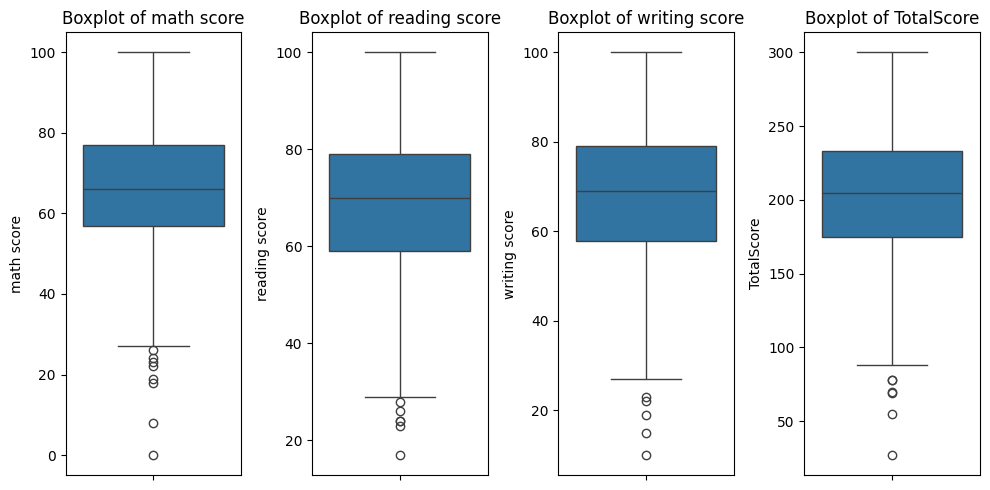

In [126]:
# Outlier Detection for Numerical columns using BOX-plot

Numerical_col= df.select_dtypes(include='number').columns
Numerical_col

plt.figure(figsize=(10, 5))
for i, column in enumerate(Numerical_col, 1):
    plt.subplot(1, len(Numerical_col), i)  # Create subplots
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

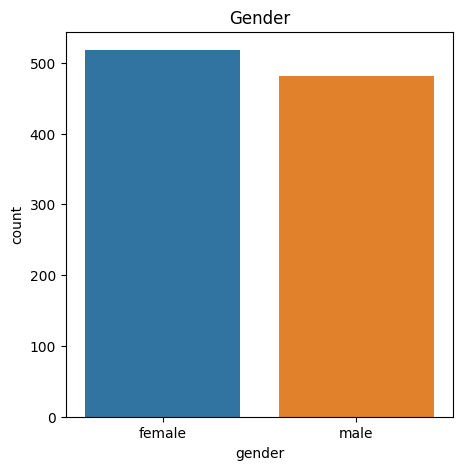

In [127]:
# Creating count plot for all categorical columns to better understand the data.

plt.figure(figsize=(5,5))
sns.countplot(x=df['gender'],hue=df['gender'])
plt.title('Gender')
plt.show()

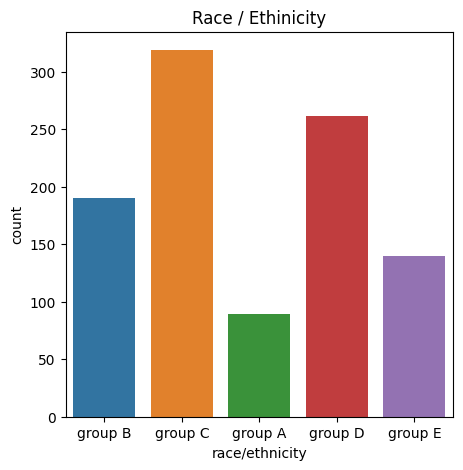

In [128]:
plt.figure(figsize=(5,5))
sns.countplot(x=df['race/ethnicity'],hue=df['race/ethnicity'])
plt.title('Race / Ethinicity')
plt.show()


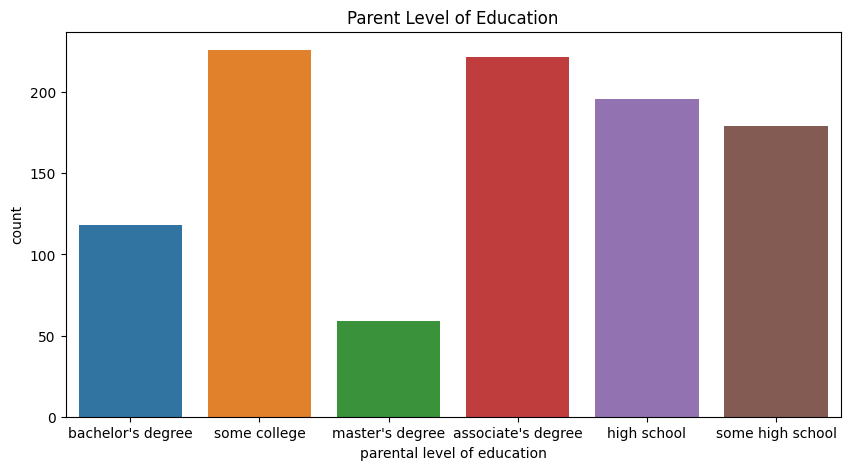

In [129]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['parental level of education'],hue=df['parental level of education'])
plt.title('Parent Level of Education')
plt.show()

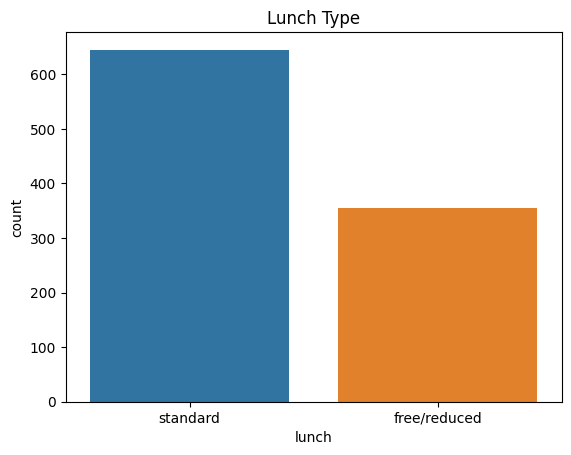

In [130]:
sns.countplot(x=df['lunch'],hue=df['lunch'])
plt.title('Lunch Type')
plt.show()

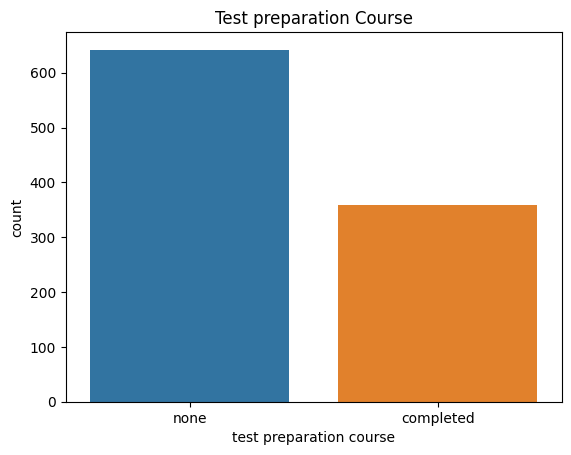

In [131]:
sns.countplot(x=df['test preparation course'],hue=df['test preparation course'])
plt.title('Test preparation Course')
plt.show()

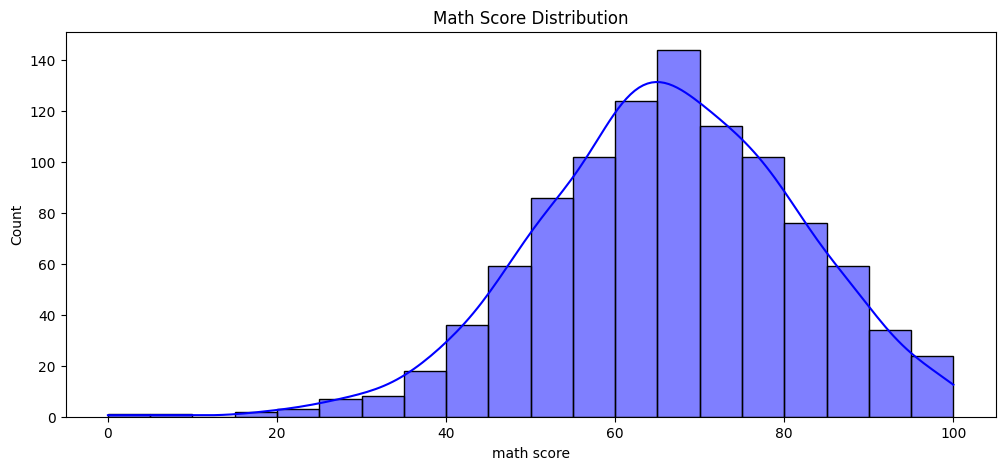

In [132]:
plt.figure(figsize=(12,5))
sns.histplot(df["math score"], bins=20, kde=True, color='blue')
plt.title("Math Score Distribution")
plt.show()

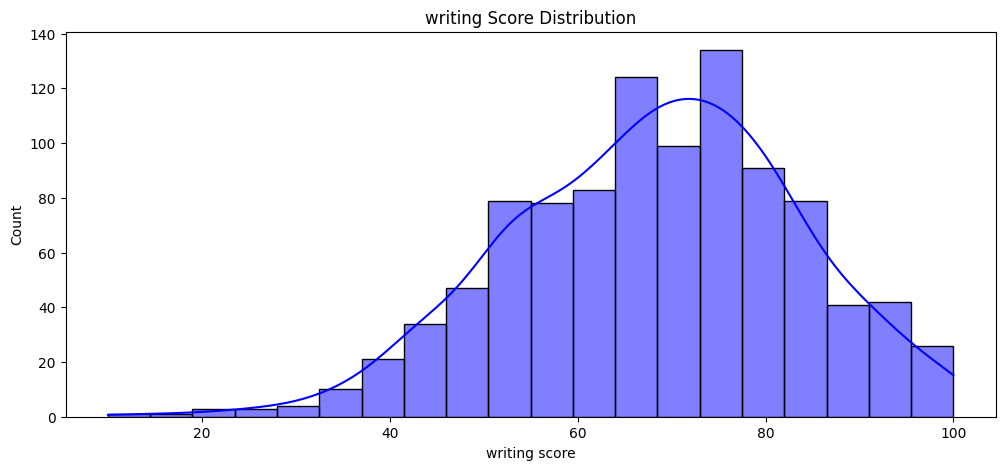

In [133]:
plt.figure(figsize=(12,5))
sns.histplot(df["writing score"], bins=20, kde=True, color='blue')
plt.title("writing Score Distribution")
plt.show()

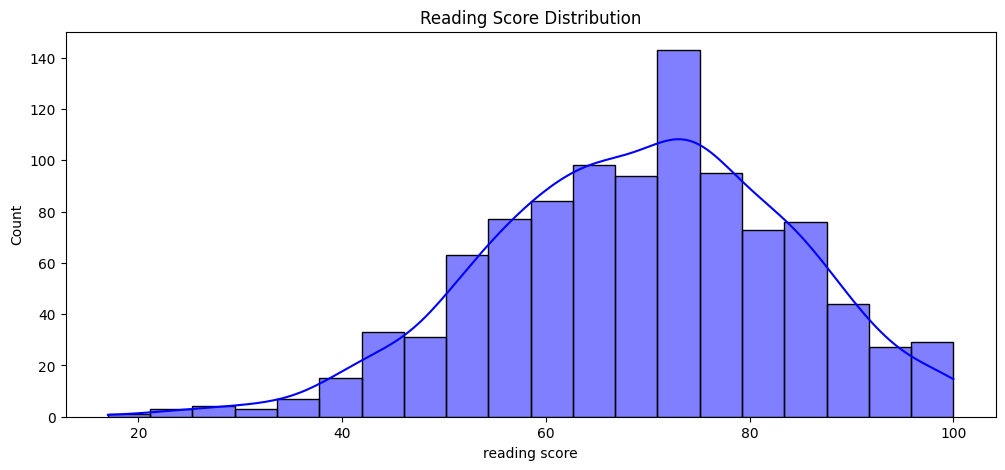

In [134]:
plt.figure(figsize=(12,5))
sns.histplot(df["reading score"], bins=20, kde=True, color='blue')
plt.title("Reading Score Distribution")
plt.show()

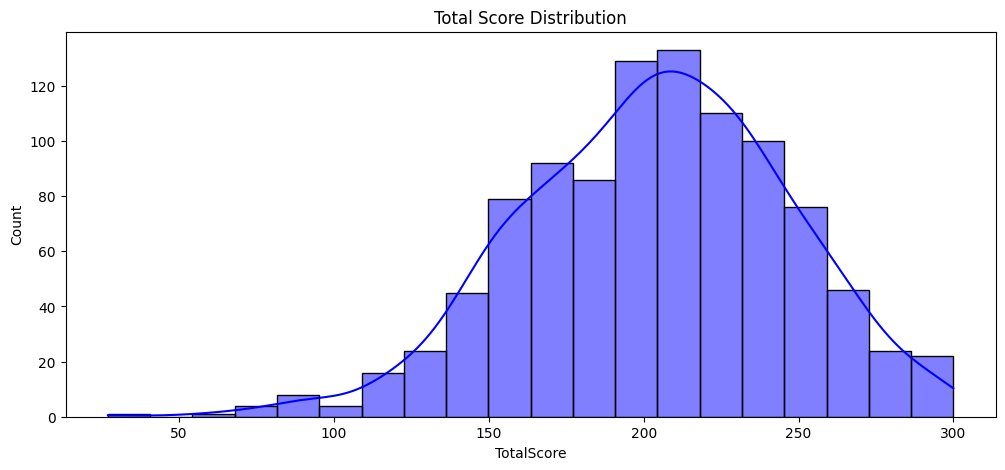

In [135]:
plt.figure(figsize=(12,5))
sns.histplot(df["TotalScore"], bins=20, kde=True, color='blue')
plt.title("Total Score Distribution")
plt.show()

## Applying Sampling Technique

Sampling is crucial when working with large datasets, as it helps analyze a representative subset instead of the entire population.

Here I am using Random Sampling to get the unbiased sample that represents the entire dataset.

In [136]:
# Perform Simple Random Sampling (select 30 random students)
sample_df = df.sample(n=30, random_state=42)

In [137]:
sample_df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,TotalScore
521,female,group C,associate's degree,standard,none,91,86,84,261
737,female,group B,some college,free/reduced,completed,53,66,73,192
740,male,group D,bachelor's degree,standard,none,80,73,72,225
660,male,group C,some college,free/reduced,none,74,77,73,224
411,male,group E,some college,standard,completed,84,83,78,245


In [138]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 521 to 947
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       30 non-null     object
 1   race/ethnicity               30 non-null     object
 2   parental level of education  30 non-null     object
 3   lunch                        30 non-null     object
 4   test preparation course      30 non-null     object
 5   math score                   30 non-null     int64 
 6   reading score                30 non-null     int64 
 7   writing score                30 non-null     int64 
 8   TotalScore                   30 non-null     int64 
dtypes: int64(4), object(5)
memory usage: 2.3+ KB


In [139]:
# Checking if the distribution of gender is unibiased or not
sample_df['gender'].value_counts()

,count
gender,
male,16
female,14


## Descriptive Analysis


## Central Tendency and dispersion measure for both sample and population


In [140]:
def descriptive_stats(column):
    stats_dict = {
        "Mean": np.mean(column),
        "Median": np.median(column),
        "Mode": stats.mode(column, keepdims=True)[0][0],
        "Variance": np.var(column, ddof=1),
        "Standard Deviation": np.std(column, ddof=1),
        "Min": np.min(column),
        "Max": np.max(column)
    }
    return stats_dict

math_stats = descriptive_stats(df["math score"])
reading_stats = descriptive_stats(df["reading score"])
writing_stats = descriptive_stats(df["writing score"])
Total_stats=descriptive_stats(df["TotalScore"])
print("Math Score Statistics:", math_stats)
print("Reading Score Statistics:", reading_stats)
print("Writing Score Statistics:", writing_stats)
print("Total Score Statistics:", Total_stats)

Math Score Statistics: {'Mean': 66.089, 'Median': 66.0, 'Mode': 65, 'Variance': 229.91899799799847, 'Standard Deviation': 15.163080096009468, 'Min': 0, 'Max': 100}
Reading Score Statistics: {'Mean': 69.169, 'Median': 70.0, 'Mode': 72, 'Variance': 213.1656046046047, 'Standard Deviation': 14.60019193725222, 'Min': 17, 'Max': 100}
Writing Score Statistics: {'Mean': 68.054, 'Median': 69.0, 'Mode': 74, 'Variance': 230.90799199199168, 'Standard Deviation': 15.195657010869642, 'Min': 10, 'Max': 100}
Total Score Statistics: {'Mean': 203.312, 'Median': 205.0, 'Mode': 204, 'Variance': 1829.4420980981006, 'Standard Deviation': 42.77197795400746, 'Min': 27, 'Max': 300}


## Identifying Outlier using IQR and Z-Score Method

In [141]:
# IQR method

# Compute Q1, Q3, and IQR
Q1 = df['TotalScore'].quantile(0.25)
Q3 = df['TotalScore'].quantile(0.75)
IQR = Q3 - Q1

In [142]:
# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['TotalScore'] < lower_bound) | (df['TotalScore'] > upper_bound)]
print("Outliers using IQR method:\n", outliers['TotalScore'])

Outliers using IQR method:
 17     78
59     27
76     78
327    70
596    69
980    55
Name: TotalScore, dtype: int64


In [143]:
from scipy import stats

# Compute Z-scores
df['Z-Score'] = np.abs(stats.zscore(df['TotalScore']))

# Define threshold (3 standard deviations)
threshold = 3

# Detect outliers
outliers_z = df[df['Z-Score'] > threshold]
print("Outliers using Z-Score method:\n", outliers_z['TotalScore'])


Outliers using Z-Score method:
 59     27
327    70
596    69
980    55
Name: TotalScore, dtype: int64


## Inferential Statistics

#### Confidence Interval

In [144]:

# Confidence Interval Calculation
def confidence_interval(column, confidence=0.95):
    n = len(column)
    mean = np.mean(column)
    std_err = stats.sem(column)
    margin = stats.t.ppf((1 + confidence) / 2, df=n-1) * std_err
    return mean - margin, mean + margin

# For maths score
math_ci = confidence_interval(df["math score"])
print(f"95% Confidence Interval for Math Scores: {math_ci}")


95% Confidence Interval for Math Scores: (65.14805983128305, 67.02994016871695)


In [145]:
reading_ci = confidence_interval(df["reading score"])
print(f"95% Confidence Interval for reading Scores: {reading_ci}")

95% Confidence Interval for reading Scores: (68.26298967902613, 70.07501032097386)


In [146]:
writing_ci = confidence_interval(df["writing score"])
print(f"95% Confidence Interval for writing Scores: {writing_ci}")

95% Confidence Interval for writing Scores: (67.11103828107223, 68.99696171892778)


In [147]:
Total_ci = confidence_interval(df["TotalScore"])
print(f"95% Confidence Interval for Total Scores: {Total_ci}")

95% Confidence Interval for Total Scores: (200.6577983537927, 205.9662016462073)


#### Hypothesis Testing

Here we will create various hypthesis about popuation dara and then will verify it using sample data


1. Gender vs Total score of students¶

     Ho -> Score of students is same for both Male and Female

     Ha -> Score may vary for Gender wise


In [148]:
# alpha value is 5% and we are performing t-test here because we don't now population sigma
alpha=0.05
male_score=df[df['gender']=='male']['TotalScore']
female_score=df[df['gender']=='female']['TotalScore']
tstat,pvalue=ttest_ind(male_score,female_score,alternative='two-sided')
if pvalue<alpha:
    print('p-value: ',pvalue)
    print('We reject Null hypothesis and we can conclude that Score is dependent on Gender')
else:
    print('We fail to reject Null Hypthesis')

p-value:  3.311973638243664e-05
We reject Null hypothesis and we can conclude that Score is dependent on Gender


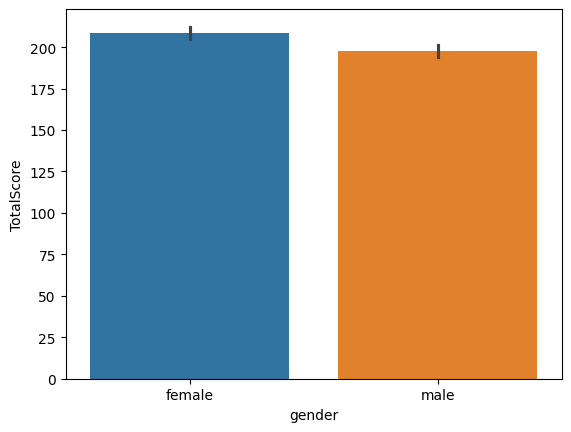

In [149]:
sns.barplot(data=df,x='gender',y='TotalScore', hue= 'gender')
plt.show()

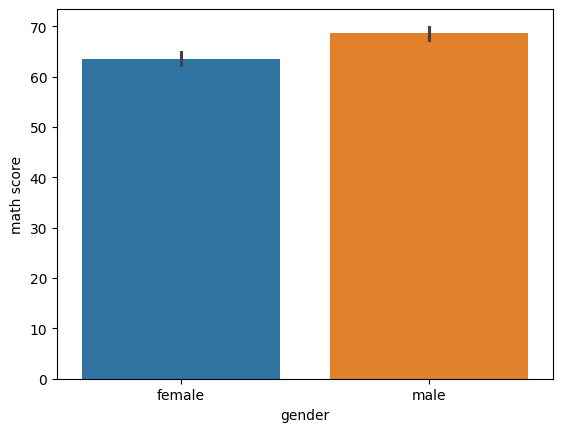

In [150]:
sns.barplot(x=df['gender'],y=df['math score'], hue=df['gender'])
plt.show()

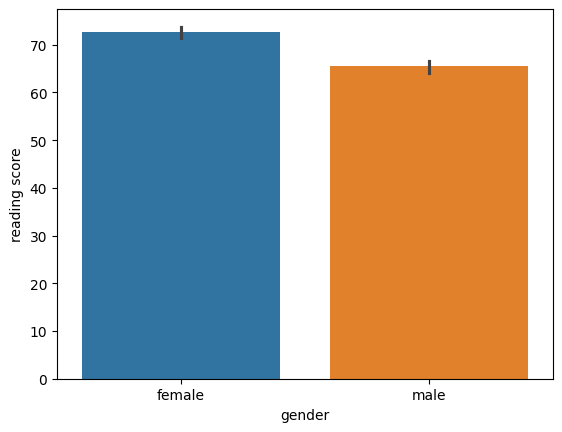

In [151]:
sns.barplot(x=df['gender'],y=df['reading score'], hue=df['gender'])
plt.show()

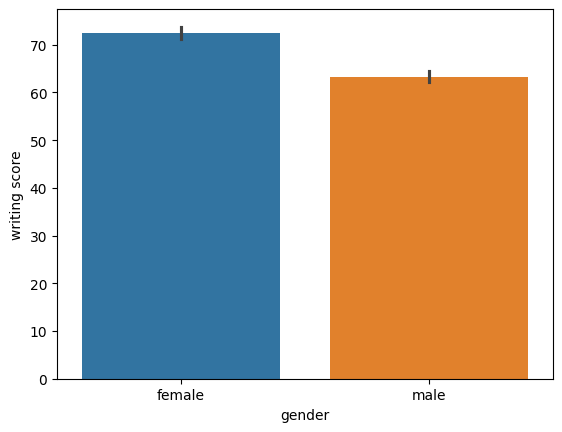

In [152]:
sns.barplot(x=df['gender'],y=df['writing score'],hue=df['gender'])
plt.show()

Conclusion : We conclude that Female students score more marks overall compared to Male students

Girls score more in reading and writing category compared to boys

Boys score more in math compared to Girls


2. Race/Ethincity vs Total Score¶

  Ho -> Score of students is same for all Race.

  Ha -> Score may vary for all Race.

In [153]:
# Applying Annova because we have 4 groups
groupA=df[df['race/ethnicity']=='group A']['TotalScore']
groupB=df[df['race/ethnicity']=='group B']['TotalScore']
groupC=df[df['race/ethnicity']=='group C']['TotalScore']
groupD=df[df['race/ethnicity']=='group D']['TotalScore']
fstat,pvalue=f_oneway(groupA,groupB,groupC,groupD)
if pvalue<alpha:
    print('p-value: ',pvalue)
    print('We reject Null hypothesis and we can conclude that Score is dependent on Race/Ethincity')
else:
    print('We fail to reject Null Hypthesis')

p-value:  0.0011736349203983238
We reject Null hypothesis and we can conclude that Score is dependent on Race/Ethincity


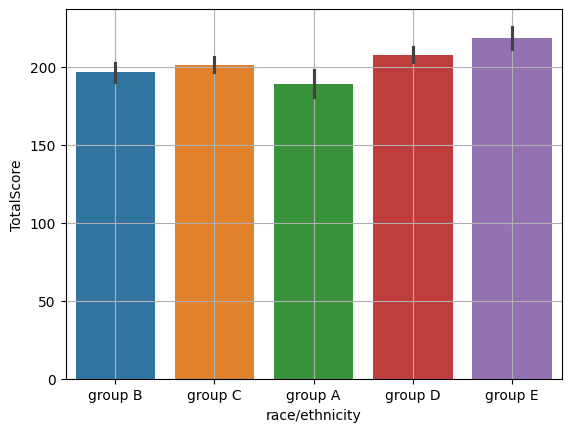

In [154]:
sns.barplot(data=df,x='race/ethnicity',y='TotalScore',hue='race/ethnicity')
plt.grid()
plt.show()

3. Parental level of Education vs Total Score¶

   Ho -> Score of students is same for all level of educations of parents.

   Ha -> Score may vary for level of educations of parents.

In [155]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [156]:
bachelor=df[df['parental level of education']=="bachelor's degree"]['TotalScore']
college=df[df['parental level of education']=="some college"]['TotalScore']
masters=df[df['parental level of education']=="master's degree"]['TotalScore']
associate=df[df['parental level of education']=="associate's degree"]['TotalScore']
highschool=df[df['parental level of education']=="high school"]['TotalScore']
sub_highschool=df[df['parental level of education']=="some high school"]['TotalScore']
fstat,pvalue=f_oneway(bachelor,college,masters,associate,highschool,sub_highschool)
if pvalue<alpha:
    print('p-value: ',pvalue)
    print('We reject Null hypothesis and we can conclude that Score is dependent for all level of educations of parents.')
else:
    print('p-value: ',pvalue)
    print('We fail to reject Null Hypthesis,we conclude that students score are independent for all level of educations of parents.')

p-value:  4.3810464809431664e-10
We reject Null hypothesis and we can conclude that Score is dependent for all level of educations of parents.


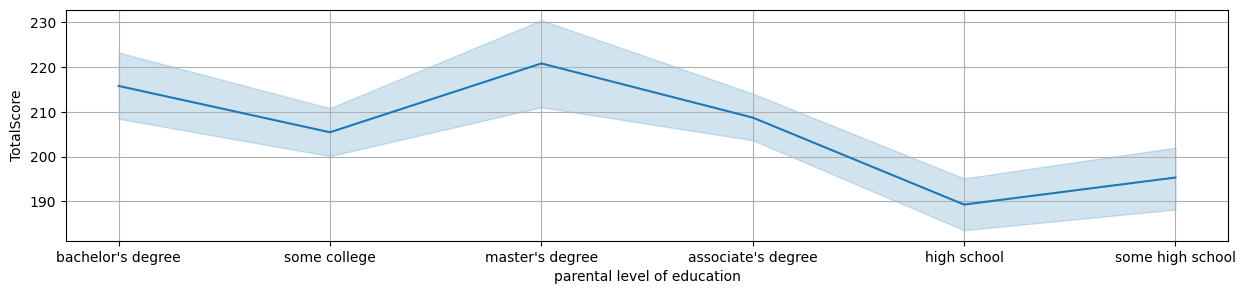

In [157]:
plt.figure(figsize=(15,3))
sns.lineplot(data=df,x='parental level of education',y='TotalScore')
plt.grid()
plt.show()

Conclusion:

We can notice that students score more if there parent's level of education is Master's degree followed by Bachelor's degree.

When the parent's level of education is Highschool or some high school then the score is very less. School should pay extra attention to such kind.

4. Lunch vs Total Score

  Ho -> Score of students is same for all lunch type.

  Ha -> Score of student with Lunch= Standard is higher

In [158]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [159]:
# One tailed T-test for two samples

standard=df[df['lunch']=="standard"]['TotalScore']
free=df[df['lunch']=="free/reduced"]['TotalScore']
tstat,pvalue=ttest_ind(standard,free,alternative='greater')
if pvalue<alpha:
    print('p-value: ',pvalue)
    print('We reject Null hypothesis and we can conclude that Score is dependent on lunch type.')
else:
    print('p-value: ',pvalue)
    print('We fail to reject Null Hypthesis,we conclude that students score are independent on lunch type.')

p-value:  3.868395906247775e-21
We reject Null hypothesis and we can conclude that Score is dependent on lunch type.


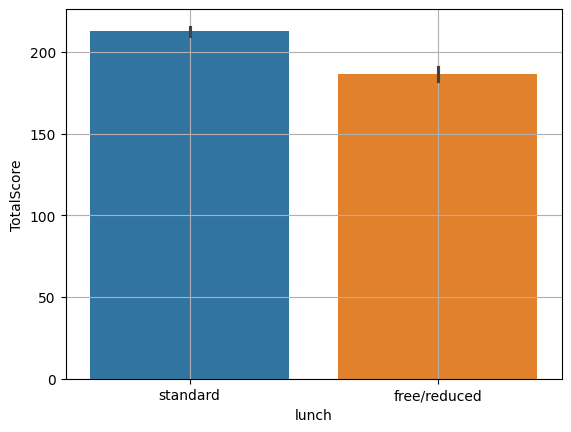

In [160]:
sns.barplot(data=df,x='lunch',y='TotalScore', hue='lunch')
plt.grid()
plt.show()

Conclusion:

We can notice that students score more if lunch type is standard, so school should infrom students to prefer standard lunch

5. Test preparation course status vs TotalScore

   Ho -> The score of Completed test preparation course students are same as None

   Ho -> The score of Completed test preparation course students are greater then None

In [161]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

In [162]:
none=df[df['test preparation course']=='none']['TotalScore']
completed=df[df['test preparation course']=='completed']['TotalScore']
ttest_ind(none,completed,alternative='less')
if pvalue<alpha:
    print('p-value: ',pvalue)
    print('We reject Null hypothesis and we can conclude that Score is dependent on test preparation course status.')
else:
    print('p-value: ',pvalue)
    print('We fail to reject Null Hypthesis,we conclude that students score are independent on test preparation course status.')

p-value:  3.868395906247775e-21
We reject Null hypothesis and we can conclude that Score is dependent on test preparation course status.


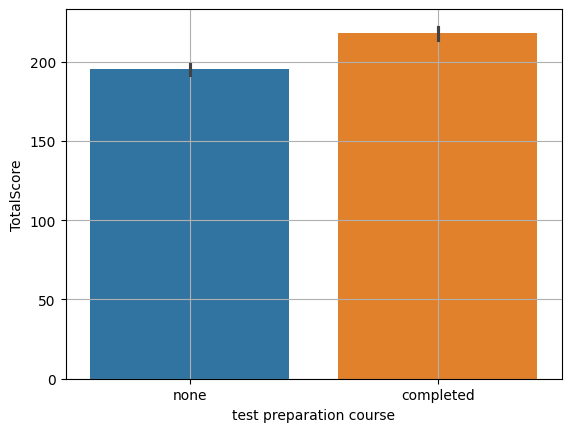

In [163]:
sns.barplot(data=df,x='test preparation course',y='TotalScore', hue='test preparation course')
plt.grid()
plt.show()

Conclusion:

We can notice that students score more if test preparation course, so school should infrom students to complete the course for better results

6. Does Race depends on Lunch Type of students?

   Ho-> Preference of Lunch is not dependent on Race

   Ha-> Preference of Lunch is dependent on Race

In [164]:
contingency=pd.crosstab(df['lunch'],df['race/ethnicity'])
contingency

race/ethnicity,group A,group B,group C,group D,group E
lunch,,,,,
free/reduced,36,69,114,95,41
standard,53,121,205,167,99


In [165]:
# Using Chi2 test because we have categorical values

from scipy.stats import chi2_contingency
cstat,pvalue,dof,expected=chi2_contingency(contingency)
if pvalue<alpha:
    print('p-value: ',pvalue)
    print('We reject Null hypothesis and we can conclude that  Preference of Lunch is dependent on Race')
else:
    print('p-value: ',pvalue)
    print('We fail to reject Null Hypthesis,we conclude that Preference of Lunch is not dependent on Race')

p-value:  0.48669808284196514
We fail to reject Null Hypthesis,we conclude that Preference of Lunch is not dependent on Race


 7. Do we have any preference observation in Gender and Lunch type selection?¶

    Ho-> Preference of Lunch is not dependent on gender

    Ha-> Preference of Lunch is dependent on gender

In [166]:
contingency=pd.crosstab(df['lunch'],df['gender'])
contingency

gender,female,male
lunch,,
free/reduced,189,166
standard,329,316


In [167]:
cstat,pvalue,dof,expected=chi2_contingency(contingency)
if pvalue<alpha:
    print('p-value: ',pvalue)
    print('We reject Null hypothesis and we can conclude that  Preference of Lunch is dependent on gender')
else:
    print('p-value: ',pvalue)
    print('We fail to reject Null Hypthesis,we conclude that Preference of Lunch is not dependent on gender')

p-value:  0.5420584175146086
We fail to reject Null Hypthesis,we conclude that Preference of Lunch is not dependent on gender


8. Does Parental Level of education has any difference in Test preparation
   course status?
   Ho-> Test preparation course status is not dependent on parental level of education

   Ha->Test preparation course status is dependent on parental level of education

In [168]:
contingency=pd.crosstab(df['test preparation course'],df['parental level of education'])
contingency

parental level of education,associate's degree,bachelor's degree,high school,master's degree,some college,some high school
test preparation course,,,,,,
completed,82,46,56,20,77,77
none,140,72,140,39,149,102


In [169]:
cstat,pvalue,dof,expected=chi2_contingency(contingency)
if pvalue<alpha:
    print('p-value: ',pvalue)
    print('We reject Null hypothesis and we can conclude that Test preparation course status is dependent on parental level of education')
else:
    print('p-value: ',pvalue)
    print('We fail to reject Null Hypthesis,we conclude that Test preparation course status is not dependent on parental level of education')

p-value:  0.08923388625809343
We fail to reject Null Hypthesis,we conclude that Test preparation course status is not dependent on parental level of education


9. Does Parental level of education depends on Lunch type preference?

   Ho-> Preference of Lunch is not dependent on parental level of education

   Ha-> Preference of Lunch is dependent on parental level of education

In [170]:
contingency=pd.crosstab(df['lunch'],df['parental level of education'])
contingency

parental level of education,associate's degree,bachelor's degree,high school,master's degree,some college,some high school
lunch,,,,,,
free/reduced,77,44,70,24,79,61
standard,145,74,126,35,147,118


In [171]:
cstat,pvalue,dof,expected=chi2_contingency(contingency)
if pvalue<alpha:
    print('p-value: ',pvalue)
    print('We reject Null hypothesis and we can conclude that  Preference of Lunch is dependent on parental level of education')
else:
    print('p-value: ',pvalue)
    print('We fail to reject Null Hypthesis,we conclude that Preference of Lunch is not dependent on parental level of education')

p-value:  0.9531014927218224
We fail to reject Null Hypthesis,we conclude that Preference of Lunch is not dependent on parental level of education


# Final Conclusion

from all the hypothesis testing, we can conclude that all the variables like gender, race, parental education, lunch type, course status have impact on scores of student and as per testing schoold should make reforms in order to achieve high scores.